FIRST 5 ROWS
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

MISSING VALUES
label      0
message    0
dtype: int64

DATASET SHAPE
(5169, 2)

CLEANED DATASET SAVED

PROCESSED DATA SAVED

MODEL TRAINED SUCCESSFULLY

PREDICTIONS
[0 1 0 0 1 0 0 0 1 0]

ACCURACY
0.9758220502901354

CONFUSION MATRIX
[[878  16]
 [  9 131]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       894
           1       0.89      0.94      0.91       140

    accuracy                           0.98      1034
   macro avg       0.94      0.96      0.95      1034
weighted avg       0.98      0.98      0.98      1034


PREDICTIONS SAVED


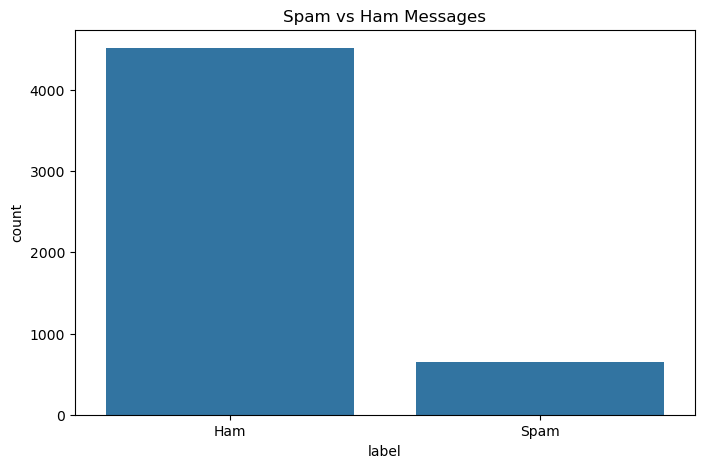


NEW MESSAGE PREDICTION
Spam Message


In [2]:
# ==========================================
# NAIVE BAYES - SMS SPAM CLASSIFIER
# COMPLETE PROFESSIONAL ML PROJECT
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs(
    "../../../datasets/cleaned/naive_bayes",
    exist_ok=True
)

os.makedirs(
    "../../../datasets/processed/naive_bayes",
    exist_ok=True
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv(
    "../../../datasets/raw/sms_spam/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("FIRST 5 ROWS")
print(df.head())

# ==========================================
# 2. CLEANING
# ==========================================

# Remove duplicates

df = df.drop_duplicates()

# Remove missing values

df = df.dropna()

# Convert labels to numeric

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDATASET SHAPE")
print(df.shape)

# ==========================================
# 3. SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "../../../datasets/cleaned/naive_bayes/cleaned_spam.csv",
    index=False
)

print("\nCLEANED DATASET SAVED")

# ==========================================
# 4. FEATURE SELECTION
# ==========================================

X = df["message"]

y = df["label"]

# ==========================================
# 5. TEXT VECTORIZATION
# ==========================================

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)

# ==========================================
# 6. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 7. SAVE PROCESSED DATASETS
# ==========================================

processed_train = pd.DataFrame(
    X_train.toarray()
)

processed_test = pd.DataFrame(
    X_test.toarray()
)

processed_train.to_csv(
    "../../../datasets/processed/naive_bayes/X_train.csv",
    index=False
)

processed_test.to_csv(
    "../../../datasets/processed/naive_bayes/X_test.csv",
    index=False
)

print("\nPROCESSED DATA SAVED")

# ==========================================
# 8. CREATE MODEL
# ==========================================

model = MultinomialNB()

# ==========================================
# 9. TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    y_train
)

print("\nMODEL TRAINED SUCCESSFULLY")

# ==========================================
# 10. PREDICTIONS
# ==========================================

predictions = model.predict(X_test)

print("\nPREDICTIONS")
print(predictions[:10])

# ==========================================
# 11. EVALUATION
# ==========================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nACCURACY")
print(accuracy)

print("\nCONFUSION MATRIX")
print(confusion_matrix(
    y_test,
    predictions
))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test,
    predictions
))

# ==========================================
# 12. SAVE PREDICTIONS
# ==========================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.to_csv(
    "../../../datasets/processed/naive_bayes/predictions.csv",
    index=False
)

print("\nPREDICTIONS SAVED")

# ==========================================
# 13. VISUALIZATION
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=df["label"]
)

plt.title("Spam vs Ham Messages")

plt.xticks(
    [0, 1],
    ["Ham", "Spam"]
)

plt.show()

# ==========================================
# 14. PREDICT NEW MESSAGE
# ==========================================

new_message = [
    "Congratulations! You won a free iPhone"
]

new_message_vector = vectorizer.transform(
    new_message
)

prediction = model.predict(
    new_message_vector
)

print("\nNEW MESSAGE PREDICTION")

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

# ==========================================
# END
# ==========================================